## Test

In [3]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/Holstein5.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['electron occupations array']

df = pd.DataFrame(df)
df.to_excel('Holstein5_16bd_singleset.xlsx', index=False)

### Plot RMSD




文件       : Holstein5_16bd_singleset.xlsx
Time steps : 101,  Number of sites : 5
第0行      : [3.67244856e-20 8.99917601e-20 1.00000000e+00 9.27154334e-20
 3.58161272e-20]
第0行之和  : 1.000000
第0行是否对应 t=0 初态: True
时间轴：从 0 开始，无偏移

文件       : Holstein5_16bd_multiset.xlsx
Time steps : 500,  Number of sites : 5
第0行      : [1.e-20 1.e-20 1.e+00 1.e-20 1.e-20]
第0行之和  : 1.000000
第0行是否对应 t=0 初态: True
时间轴：从 0 开始，无偏移

文件       : Holstein5_64bd_singleset.xlsx
Time steps : 101,  Number of sites : 5
第0行      : [8.28031485e-20 2.24744759e-19 1.00000000e+00 2.24744831e-19
 8.28031537e-20]
第0行之和  : 1.000000
第0行是否对应 t=0 初态: True
时间轴：从 0 开始，无偏移

文件       : Holstein5_64bd_multiset.xlsx
Time steps : 500,  Number of sites : 5
第0行      : [1.e-20 1.e-20 1.e+00 1.e-20 1.e-20]
第0行之和  : 1.000000
第0行是否对应 t=0 初态: True
时间轴：从 0 开始，无偏移

✅ 已保存: FigS1_all4.png


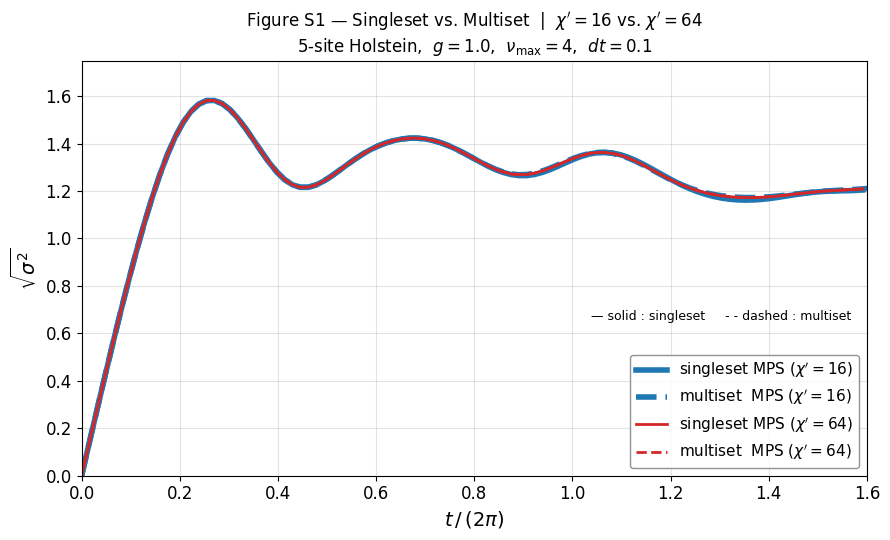

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0. 通用函数定义
# =========================

def compute_rmsd(file_path, dt=0.1):
    """
    读取 Excel 文件，计算每个时间步的 RMSD。
    返回: time_scaled, rmsd
    """
    df    = pd.read_excel(file_path, header=None)
    occup = df.values          # shape: (Nt, Nsite)
    Nt, Nsite = occup.shape

    print(f"\n{'='*55}")
    print(f"文件       : {file_path}")
    print(f"Time steps : {Nt},  Number of sites : {Nsite}")
    print(f"第0行      : {occup[0]}")
    print(f"第0行之和  : {occup[0].sum():.6f}")

    # ------ 判断第0行是否为 t=0 初态 ------
    first_row_is_t0 = np.abs(occup[0, Nsite // 2] - 1.0) < 0.01
    print(f"第0行是否对应 t=0 初态: {first_row_is_t0}")

    # ------ 坐标 & 中心 ------
    x  = np.arange(Nsite)
    n0 = (Nsite - 1) / 2      # 5-site → n0 = 2.0

    # ------ 计算 RMSD ------
    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho  = occup[t].astype(float)
        norm = rho.sum()
        if norm > 1e-12:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0) ** 2 * rho))

    # ------ 时间轴 ------
    if first_row_is_t0:
        time_au = np.arange(Nt) * dt
        print("时间轴：从 0 开始，无偏移")
    else:
        time_au = np.arange(1, Nt + 1) * dt
        print("时间轴：检测到偏移，从 dt 开始")

    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd


# =========================
# 1. 定义四条曲线的配置
#    (文件名, 图例标签, 颜色, 线型, 线宽)
# =========================
datasets = [
    (
        "Holstein5_16bd_singleset.xlsx",
        r"singleset MPS ($\chi'=16$)",
        "#1f77b4",   # 蓝
        "-",
        4.0
    ),
    (
        "Holstein5_16bd_multiset.xlsx",
        r"multiset  MPS ($\chi'=16$)",
        "#1f77b4",   # 蓝（与 singleset 同色，用线型区分）
        "--",
        4.0
    ),
    (
        "Holstein5_64bd_singleset.xlsx",
        r"singleset MPS ($\chi'=64$)",
        "#d62728",   # 红
        "-",
        2.0
    ),
    (
        "Holstein5_64bd_multiset.xlsx",
        r"multiset  MPS ($\chi'=64$)",
        "#d62728",   # 红（与 singleset 同色，用线型区分）
        "--",
        2.0
    ),
]

# =========================
# 2. 逐一读取并计算 RMSD
# =========================
results = []
for (fpath, label, color, ls, lw) in datasets:
    t_sc, rmsd = compute_rmsd(fpath)
    results.append((t_sc, rmsd, label, color, ls, lw))

# =========================
# 3. 汇总到同一张图
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))

for (t_sc, rmsd, label, color, ls, lw) in results:
    ax.plot(t_sc, rmsd,
            color=color, ls=ls, lw=lw,
            label=label)

# ------ 坐标轴 ------
ax.set_xlim(0, 1.6)
ax.set_ylim(0, 1.75)
ax.set_xlabel(r"$t\,/\,(2\pi)$",  fontsize=14)
ax.set_ylabel(r"$\sqrt{\sigma^2}$", fontsize=14)
ax.tick_params(labelsize=12)

# ------ 标题 ------
ax.set_title(
    "Figure S1 — Singleset vs. Multiset  |  "
    r"$\chi'=16$ vs. $\chi'=64$"
    "\n"
    r"5-site Holstein,  $g=1.0$,  $\nu_{\max}=4$,  $dt=0.1$",
    fontsize=12
)

# ------ 图例（手动加两条"虚拟"分隔说明，更清晰）------
ax.legend(
    fontsize=11,
    framealpha=0.85,
    edgecolor="gray",
    loc="lower right"
)

# ------ 辅助线：区分 singleset / multiset ------
# 在图例下方加一行说明
ax.text(
    0.98, 0.4,
    "— solid : singleset     - - dashed : multiset",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=9, color="black"
)

ax.grid(True, alpha=0.35)

plt.tight_layout()
# plt.savefig("FigS1_all4.png", dpi=150)
print("\n✅ 已保存: FigS1_all4.png")
plt.show()

## Comparison

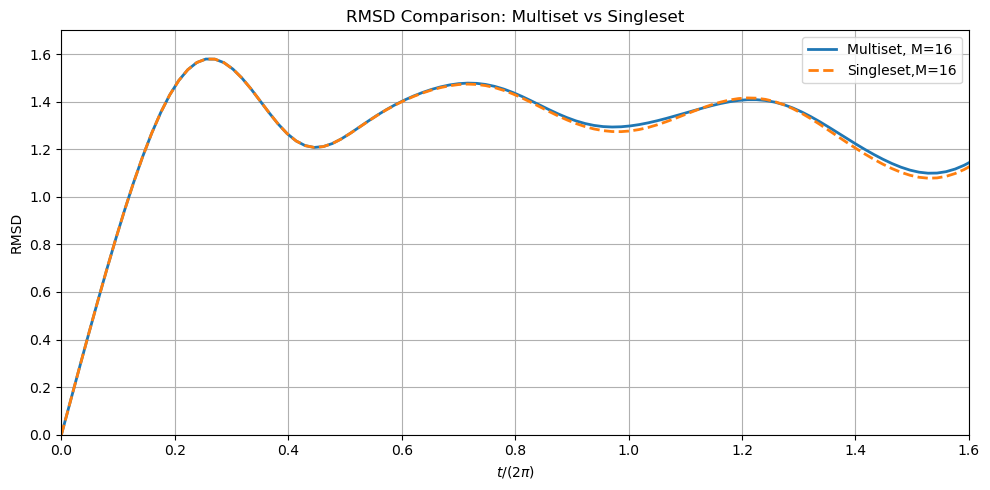

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 公共参数
# =========================
dt = 0.1          # a.u.
scale = 1/(2*np.pi)  # t / (2/pi)

# =========================
# RMSD 计算函数
# =========================
def compute_rmsd_from_excel(file_path):
    """
    读取 Excel 文件并计算 RMSD(t)
    """
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # (Nt, Nsite)

    Nt, Nsite = occup.shape
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)

    for t in range(Nt):
        n_t = occup[t]

        # 归一化（防止数值误差）
        n_t = n_t / np.sum(n_t)

        x_mean = np.sum(x * n_t)
        x2_mean = np.sum(x**2 * n_t)

        rmsd[t] = np.sqrt(x2_mean - x_mean**2)

    time = np.arange(Nt) * dt * scale
    return time, rmsd


# =========================
# 读取并计算 RMSD
# =========================
file_multi = "Holstein5_16bd_multiset.xlsx"
file_single = "Holstein5_16bd_singleset.xlsx"

time_m, rmsd_m = compute_rmsd_from_excel(file_multi)
time_s, rmsd_s = compute_rmsd_from_excel(file_single)

# =========================
# 作对比图
# =========================
plt.figure(figsize=(10, 5))

plt.plot(time_m, rmsd_m, lw=2, label="Multiset, M=16")
plt.plot(time_s, rmsd_s, lw=2, ls="--", label="Singleset,M=16")

plt.xlabel(r"$t / (2\pi)$")
plt.ylabel("RMSD")
plt.xlim(0,1.6)
plt.ylim(0,1.7)
plt.title("RMSD Comparison: Multiset vs Singleset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()